<a href="https://colab.research.google.com/github/hkawuwa/Fourier-Transform-Denoising/blob/main/A_Hybrid_EfficientNet_and_Support_Vector_Machine_Approach_for_Skin_Lesion_Classification_in_Skin_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup and Google Drive Mounting

import os
import pandas as pd
import numpy as np
from google.colab import drive
import cv2
from tqdm import tqdm

# Mount Google Drive
print("1. Mounting Google Drive...")
drive.mount('/content/drive')

# Install required image processing and deep learning libraries
print("2. Installing necessary libraries (timm, torchmetrics, medpy)...")
!pip install torchmetrics timm medpy -qq

print("Setup Complete.")

1. Mounting Google Drive...
Mounted at /content/drive
2. Installing necessary libraries (timm, torchmetrics, medpy)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.1 MB/s eta 0:00:00
Setup Complete.


In [ ]:
#  Define Paths and Configuration

import os
import pandas as pd
import numpy as np

# The main directory containing your ISIC 2019 data
ISIC_PARENT_DIR = '/content/drive/MyDrive/ISIC2019'

# Define paths for the raw data files
METADATA_PATH = os.path.join(ISIC_PARENT_DIR, 'ISIC_2019_Training_Metadata.csv')
GROUND_TRUTH_PATH = os.path.join(ISIC_PARENT_DIR, 'ISIC_2019_Training_GroundTruth.csv')

# --- PHASE I & II Output Directories ---
# Directory for the balanced metadata files (train/val/test.csv)
METADATA_DIR = os.path.join(ISIC_PARENT_DIR, 'Curated_Balanced_5k_DATA')

# *** REPLACED: This path is no longer needed/used for reading raw images. ***
# *** The recursive scan in Cell 5 uses ISIC_PARENT_DIR directly. ***
RAW_IMAGE_DIR = None

# The new directory where cleaned images will be saved
CLEAN_IMAGE_DIR = os.path.join(ISIC_PARENT_DIR, 'Cleaned_DullRazor_Images')

# Create necessary output directories
if not os.path.exists(METADATA_DIR):
    os.makedirs(METADATA_DIR)
    print(f"Created metadata output directory: {METADATA_DIR}")
if not os.path.exists(CLEAN_IMAGE_DIR):
    os.makedirs(CLEAN_IMAGE_DIR)
    print(f"Created cleaned images output directory: {CLEAN_IMAGE_DIR}")

print("Paths and initial directories configured.")
print("Note: Raw image files will be found using a recursive scan of the parent directory in Cell 5.")

Paths and initial directories configured.
Note: Raw image files will be found using a recursive scan of the parent directory in Cell 5.


In [ ]:
#  Load and Merge Metadata

print("1. Loading and merging metadata...")

try:
    df_meta = pd.read_csv(METADATA_PATH)
    df_gt = pd.read_csv(GROUND_TRUTH_PATH)

    # Convert one-hot encoded ground truth to a single label column
    df_gt['label'] = df_gt.iloc[:, 1:].idxmax(axis=1)

    # Merge the metadata and the label column
    df_master = pd.merge(df_meta, df_gt[['image', 'label']], on='image')
    df_master.rename(columns={'image': 'image_id'}, inplace=True)

    # Remove the unknown class
    df_master = df_master[df_master['label'] != 'UNK']

    print(f"Master DataFrame created. Total unique images: {len(df_master)}")
    print("Original Class Distribution:")
    print(df_master['label'].value_counts())

except Exception as e:
    print(f"FATAL ERROR during data loading/merging: {e}")
    raise

1. Loading and merging metadata...
Master DataFrame created. Total unique images: 25331
Original Class Distribution:
label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


In [ ]:
# Final Guaranteed Random Under/Over Sampling (Data Balancing) ---

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

print("\n--- 4.0 Executing Phase I: Data Balancing (5,000 Entries) ---")

# --- 1. Prepare Data for Simple Sampling (Image ID and Label only) ---
df_id_label = df_master[['image_id', 'label']].copy()
X_ids = df_id_label[['image_id']]
y_labels = df_id_label['label']
original_counts = y_labels.value_counts()


# --- 2. Define Target and Strategy ---
TARGET_SIZE = 5000
NUM_CLASSES = y_labels.nunique()
TARGET_SAMPLES_PER_CLASS = TARGET_SIZE // NUM_CLASSES # 625

print(f"\nTargeting a balanced set of {TARGET_SIZE} entries ({TARGET_SAMPLES_PER_CLASS} per class)...")

# Define the final target strategy for ALL classes (625 for everyone)
final_sampling_strategy = {
    label: TARGET_SAMPLES_PER_CLASS for label in y_labels.unique()
}


# --- 3. Sequential Under and Over Sampling ---

# 3.1 Stage 1: Random Under-sampling (on classes larger than 625)
rus_strategy = {}
for label, count in original_counts.items():
    rus_strategy[label] = min(count, TARGET_SAMPLES_PER_CLASS)

rus = RandomUnderSampler(sampling_strategy=rus_strategy, random_state=42)
X_partial, y_partial = rus.fit_resample(X_ids, y_labels)

# 3.2 Stage 2: Random Over-sampling (on all classes to hit the 625 target)
ros = RandomOverSampler(sampling_strategy=final_sampling_strategy, random_state=42)
X_final_resampled, y_final_resampled = ros.fit_resample(X_partial, y_partial)


# --- 4. Reconstruct Final DataFrame and Merge Metadata ---

df_final_curated = pd.DataFrame(X_final_resampled, columns=['image_id'])
df_final_curated['label'] = y_final_resampled

# Merge back the full original metadata (creates duplicate rows for oversampled image_ids)
df_final_curated = df_final_curated.merge(df_master.drop(columns=['label']),
                                         on='image_id', how='left')

print(f"Balanced Dataset created. Total entries: {len(df_final_curated)}")
print("New Class Distribution (Guaranteed Balanced):")
print(df_final_curated['label'].value_counts())


# --- 5. Final Stratified 80/10/10 Split and Save ---

df_train_val, df_test = train_test_split(
    df_final_curated,
    test_size=0.1,
    random_state=42,
    stratify=df_final_curated['label']
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=(0.1 / 0.9),
    random_state=42,
    stratify=df_train_val['label']
)

df_train.to_csv(os.path.join(METADATA_DIR, 'train.csv'), index=False)
df_val.to_csv(os.path.join(METADATA_DIR, 'val.csv'), index=False)
df_test.to_csv(os.path.join(METADATA_DIR, 'test.csv'), index=False)

print(f"\nNew Data Splits Saved in {METADATA_DIR}:")
print(f"Train Set: {len(df_train)} entries")
print(f"Validation Set: {len(df_val)} entries")
print(f"Test Set: {len(df_test)} entries")

print(" PHASE I: DATA OVERHAUL COMPLETE.")


--- 4.0 Executing Phase I: Data Balancing (5,000 Entries) ---

Targeting a balanced set of 5000 entries (625 per class)...
Balanced Dataset created. Total entries: 5000
New Class Distribution (Guaranteed Balanced):
label
AK      625
BCC     625
BKL     625
DF      625
MEL     625
NV      625
SCC     625
VASC    625
Name: count, dtype: int64

New Data Splits Saved in /content/drive/MyDrive/ISIC2019/Curated_Balanced_5k_DATA:
Train Set: 3999 entries
Validation Set: 501 entries
Test Set: 500 entries
 PHASE I: DATA OVERHAUL COMPLETE.


In [ ]:
# DullRazor Hair Removal and Image Curation

import glob # <--- ADDED THIS LINE TO FIX THE ERROR
from medpy.filter.smoothing import anisotropic_diffusion
import shutil
from PIL import Image

print("\n--- 5.0 Executing Phase II: DullRazor Pre-processing (Recursive Scan) ---")
print(f"Starting recursive scan for all raw images under: {ISIC_PARENT_DIR}")

# --- 1. Create a Master Image Path Map ---
# Searches all subdirectories (**) for files matching the ISIC_*.jpg pattern
search_pattern = os.path.join(ISIC_PARENT_DIR, '**', 'ISIC_*.jpg')
all_raw_image_paths = glob.glob(search_pattern, recursive=True)

# Create a dictionary mapping the image ID (e.g., ISIC_0000000) to its full path
image_path_map = {}
for full_path in all_raw_image_paths:
    filename = os.path.basename(full_path)
    image_id = filename.replace('.jpg', '')
    image_path_map[image_id] = full_path

print(f"Total raw images found in all subfolders: {len(image_path_map)}")
if not image_path_map:
    print("FATAL ERROR: No images found. Check that your images start with 'ISIC_' and are .jpg files.")
    raise FileNotFoundError("Image files not found in the specified structure.")


# --- 2. DullRazor Function Definition ---
def dull_razor(image):
    """Applies the DullRazor algorithm to remove hair from a skin lesion image."""
    gray_scale = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    black_hat = cv2.morphologyEx(gray_scale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(black_hat, 10, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    cleaned_image = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)
    return cleaned_image


# --- 3. Image Processing and Curation ---

# Load all unique image IDs from the balanced metadata splits
df_train = pd.read_csv(os.path.join(METADATA_DIR, 'train.csv'))
df_val = pd.read_csv(os.path.join(METADATA_DIR, 'val.csv'))
df_test = pd.read_csv(os.path.join(METADATA_DIR, 'test.csv'))

all_ids = pd.concat([df_train['image_id'], df_val['image_id'], df_test['image_id']]).unique()

print(f"\nFound {len(all_ids)} unique image IDs required for processing (from the metadata).")
print("Starting DullRazor process. This will take a long time...")

processed_count = 0
errors = []

for image_id in tqdm(all_ids, desc="Processing Images"):
    clean_path = os.path.join(CLEAN_IMAGE_DIR, f"{image_id}.jpg")

    # Check if the cleaned file already exists (for crash recovery/resumption)
    if os.path.exists(clean_path):
        processed_count += 1
        continue

    # Get the raw path from the map (using the recursive scan result)
    raw_path = image_path_map.get(image_id)
    if not raw_path:
        errors.append(f"Raw image file not found in map: {image_id}")
        continue

    try:
        # Read the image
        img = cv2.imread(raw_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply DullRazor
        cleaned_img = dull_razor(img)

        # Save the cleaned image
        cv2.imwrite(clean_path, cv2.cvtColor(cleaned_img, cv2.COLOR_RGB2BGR))
        processed_count += 1

    except Exception as e:
        errors.append(f"Error processing {image_id} at {raw_path}: {e}")

print("\n--- Processing Summary ---")
print(f"Total Unique Images Processed and Saved: {processed_count}")
print(f"Total Errors/Missing Files: {len(errors)}")
if errors:
    print("Sample of Errors:")
    for error in errors[:5]:
        print(f"- {error}")

print("\n PHASE II: IMAGE PRE-PROCESSING COMPLETE (or resumed).")


--- 5.0 Executing Phase II: DullRazor Pre-processing (Recursive Scan) ---
Starting recursive scan for all raw images under: /content/drive/MyDrive/ISIC2019
Total raw images found in all subfolders: 4242

Found 4242 unique image IDs required for processing (from the metadata).
Starting DullRazor process. This will take a long time...


Processing Images: 100%|██████████| 4242/4242 [00:00<00:00, 6034.53it/s]


--- Processing Summary ---
Total Unique Images Processed and Saved: 4242
Total Errors/Missing Files: 0

 PHASE II: IMAGE PRE-PROCESSING COMPLETE (or resumed).


In [ ]:
import os
import torch
import timm
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENSEMBLE_MODELS = [
    {"name": "efficientnet_b4", "image_size": 380, "batch_size": 16},
    {"name": "efficientnet_b5", "image_size": 456, "batch_size": 8},
]

NUM_CLASSES = 8
MAX_EPOCHS = 80
PATIENCE = 15
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

TRAIN_CSV = os.path.join(METADATA_DIR, "train.csv")
VAL_CSV   = os.path.join(METADATA_DIR, "val.csv")
TEST_CSV  = os.path.join(METADATA_DIR, "test.csv")

CLASS_NAMES = ['AK','BCC','BKL','DF','MEL','NV','SCC','VASC']


In [ ]:
class ISICDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row.image_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[row.label]
        return self.transform(image), label


In [ ]:
class CheckpointManager:
    def __init__(self, name):
        self.name = name
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False
        self.last_ckpt = f"{name}_last.pth"
        self.best_ckpt = f"{name}_best.pth"

    def save(self, state, is_best):
        torch.save(state, self.last_ckpt)
        if is_best:
            torch.save(state, self.best_ckpt)

    def load(self, model, optimizer):
        if os.path.exists(self.last_ckpt):
            print(f"🔄 Resuming {self.name}")
            ckpt = torch.load(self.last_ckpt, map_location=DEVICE)
            model.load_state_dict(ckpt["model"])
            optimizer.load_state_dict(ckpt["optimizer"])
            self.best_loss = ckpt["best_loss"]
            return ckpt["epoch"] + 1
        return 0


In [ ]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, manager):
    scaler = GradScaler()
    start_epoch = manager.load(model, optimizer)

    for epoch in range(start_epoch, MAX_EPOCHS):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()

            with autocast():
                loss = criterion(model(x), y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with autocast():
                    val_loss += criterion(model(x), y).item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        is_best = val_loss < manager.best_loss
        if is_best:
            manager.best_loss = val_loss
            manager.counter = 0
        else:
            manager.counter += 1
            if manager.counter >= PATIENCE:
                manager.early_stop = True

        manager.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_loss": manager.best_loss
        }, is_best)

        print(f"{model.__class__.__name__} | Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

        if manager.early_stop:
            print("Early stopping")
            break


In [ ]:
trained_models = []

for cfg in ENSEMBLE_MODELS:
    print(f"\n Training {cfg['name']}")

    train_tf = transforms.Compose([
        transforms.Resize((cfg["image_size"], cfg["image_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    val_tf = transforms.Compose([
        transforms.Resize((cfg["image_size"], cfg["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    train_ds = ISICDataset(TRAIN_CSV, CLEAN_IMAGE_DIR, train_tf)
    val_ds   = ISICDataset(VAL_CSV, CLEAN_IMAGE_DIR, val_tf)

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg["batch_size"]*2)

    model = timm.create_model(cfg["name"], pretrained=True, num_classes=NUM_CLASSES)
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
    criterion = torch.nn.CrossEntropyLoss()

    manager = CheckpointManager(cfg["name"])
    train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, manager)

    trained_models.append(model)



 Training efficientnet_b4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

/tmp/ipython-input-3017558390.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-3017558390.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-3017558390.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


EfficientNet | Epoch 1 | Train 1.9501 | Val 1.7987
EfficientNet | Epoch 2 | Train 1.5241 | Val 1.4904
EfficientNet | Epoch 3 | Train 1.2630 | Val 1.3262
EfficientNet | Epoch 4 | Train 1.1018 | Val 1.2235
EfficientNet | Epoch 5 | Train 0.9708 | Val 1.1714
EfficientNet | Epoch 6 | Train 0.8705 | Val 1.1430
EfficientNet | Epoch 7 | Train 0.7550 | Val 1.0809
EfficientNet | Epoch 8 | Train 0.6930 | Val 1.0696
EfficientNet | Epoch 9 | Train 0.6089 | Val 1.0730
EfficientNet | Epoch 10 | Train 0.5274 | Val 1.0669
EfficientNet | Epoch 11 | Train 0.4667 | Val 1.0573
EfficientNet | Epoch 12 | Train 0.4139 | Val 1.1041
EfficientNet | Epoch 13 | Train 0.3538 | Val 1.1053
EfficientNet | Epoch 14 | Train 0.2987 | Val 1.1882
EfficientNet | Epoch 15 | Train 0.2645 | Val 1.1742
EfficientNet | Epoch 16 | Train 0.2409 | Val 1.1304
EfficientNet | Epoch 17 | Train 0.2039 | Val 1.1780
EfficientNet | Epoch 18 | Train 0.1707 | Val 1.2026
EfficientNet | Epoch 19 | Train 0.1724 | Val 1.1954
EfficientNet | Epoch 

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

/tmp/ipython-input-3017558390.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-3017558390.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-3017558390.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


EfficientNet | Epoch 1 | Train 1.5993 | Val 1.1713
EfficientNet | Epoch 2 | Train 0.9580 | Val 1.0165
EfficientNet | Epoch 3 | Train 0.7748 | Val 0.9343
EfficientNet | Epoch 4 | Train 0.5937 | Val 0.9541
EfficientNet | Epoch 5 | Train 0.4834 | Val 0.9004
EfficientNet | Epoch 6 | Train 0.3681 | Val 0.9943
EfficientNet | Epoch 7 | Train 0.3036 | Val 0.9729
EfficientNet | Epoch 8 | Train 0.2627 | Val 0.9610
EfficientNet | Epoch 9 | Train 0.2282 | Val 1.0088
EfficientNet | Epoch 10 | Train 0.1882 | Val 1.1510
EfficientNet | Epoch 11 | Train 0.1720 | Val 1.0884
EfficientNet | Epoch 12 | Train 0.0597 | Val 1.1115
EfficientNet | Epoch 13 | Train 0.0362 | Val 1.1552
EfficientNet | Epoch 14 | Train 0.0241 | Val 1.1934
EfficientNet | Epoch 15 | Train 0.0213 | Val 1.1713
EfficientNet | Epoch 16 | Train 0.0170 | Val 1.1721
EfficientNet | Epoch 17 | Train 0.0181 | Val 1.1884
EfficientNet | Epoch 18 | Train 0.0123 | Val 1.1573
EfficientNet | Epoch 19 | Train 0.0109 | Val 1.1984
EfficientNet | Epoch 

In [ ]:
# --- CELL A: EfficientNet Feature Extractor (Remove Classifier Head) ---

import torch.nn as nn

def get_feature_extractor(trained_model):
    """
    Removes the classification head and returns feature vectors.
    """
    model = trained_model
    if hasattr(model, 'classifier'):
        model.classifier = nn.Identity()
    elif hasattr(model, 'fc'):
        model.fc = nn.Identity()
    model.eval()
    return model


In [ ]:
# --- CELL B: Deep Feature Extraction ---

from sklearn.preprocessing import StandardScaler

def extract_features(model, loader):
    features = []
    labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Extracting Features"):
            x = x.to(DEVICE)
            feats = model(x).cpu().numpy()
            features.append(feats)
            labels.append(y.numpy())

    return np.vstack(features), np.hstack(labels)


In [ ]:
# --- CELL C: Feature Extraction Loaders ---

feat_tf = transforms.Compose([
    transforms.Resize((380, 380)),   # Use B4 resolution (safe choice)
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_feat_ds = ISICDataset(TRAIN_CSV, CLEAN_IMAGE_DIR, feat_tf)
val_feat_ds   = ISICDataset(VAL_CSV, CLEAN_IMAGE_DIR, feat_tf)
test_feat_ds  = ISICDataset(TEST_CSV, CLEAN_IMAGE_DIR, feat_tf)

train_feat_loader = DataLoader(train_feat_ds, batch_size=32, shuffle=False)
val_feat_loader   = DataLoader(val_feat_ds, batch_size=32, shuffle=False)
test_feat_loader  = DataLoader(test_feat_ds, batch_size=32, shuffle=False)


In [ ]:
# --- CELL D: Feature Fusion from EfficientNet B4 + B5 ---

feature_models = [get_feature_extractor(m) for m in trained_models]

X_train_list, X_test_list = [], []

for fm in feature_models:
    X_tr, y_train = extract_features(fm, train_feat_loader)
    X_te, y_test  = extract_features(fm, test_feat_loader)
    X_train_list.append(X_tr)
    X_test_list.append(X_te)

# Concatenate features
X_train = np.concatenate(X_train_list, axis=1)
X_test  = np.concatenate(X_test_list, axis=1)

# Standardize (VERY important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Extracting Features: 100%|██████████| 16/16 [00:14<00:00,  1.09it/s]


In [ ]:
# --- CELL E: Train SVM Classifier ---

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

print("🚀 Training SVM on EfficientNet features...")
svm.fit(X_train, y_train)


🚀 Training SVM on EfficientNet features...


SVC(C=10, class_weight='balanced', probability=True, random_state=42)


📊 EfficientNet + SVM Classification Report
              precision    recall  f1-score   support

          AK       0.74      0.77      0.76        62
         BCC       0.75      0.68      0.71        62
         BKL       0.68      0.65      0.67        63
          DF       0.98      0.95      0.97        63
         MEL       0.64      0.65      0.65        63
          NV       0.62      0.66      0.64        62
         SCC       0.75      0.76      0.76        63
        VASC       0.97      1.00      0.98        62

    accuracy                           0.77       500
   macro avg       0.77      0.77      0.77       500
weighted avg       0.77      0.77      0.77       500



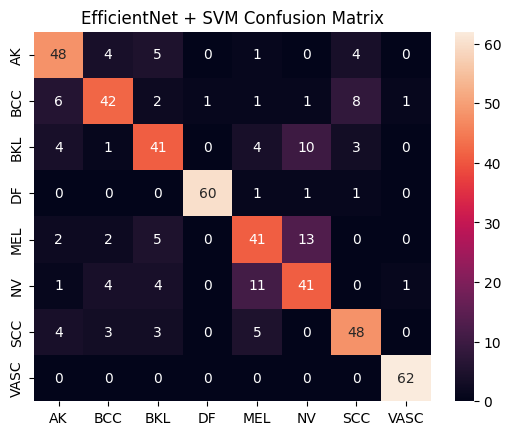

In [ ]:
# --- CELL F: EfficientNet + SVM Evaluation ---

svm_preds = svm.predict(X_test)

print("\n📊 EfficientNet + SVM Classification Report")
print(classification_report(y_test, svm_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("EfficientNet + SVM Confusion Matrix")
plt.show()


# Task
Evaluate the performance of the trained EfficientNet models (B4 and B5) and the SVM ensemble model by calculating and printing their training and testing accuracies. Additionally, generate and plot multi-class ROC curves with AUC scores for all models (EfficientNet B4, EfficientNet B5, and the EfficientNet + SVM ensemble) on the test set.

## Prepare evaluation functions and data loaders

### Subtask:
Define helper functions for calculating accuracy and ensuring appropriate data loaders (train and test) are available for making predictions with individual models.


**Reasoning**:
First, I will define the `evaluate_model_performance` function to get predictions and probabilities from a model. Then, I will define the `calculate_accuracy` function to compute accuracy given true and predicted labels. Finally, I will set up the necessary data loaders and transforms (test, train, and validation) for each model configuration as specified in the subtask instructions.



In [ ]:
import torchmetrics.functional as F

def evaluate_model_performance(model, data_loader, return_probs=False):
    """Evaluates a PyTorch model on a given data loader.

    Args:
        model (torch.nn.Module): The PyTorch model to evaluate.
        data_loader (torch.utils.data.DataLoader): The data loader for evaluation.
        return_probs (bool, optional): Whether to return predicted probabilities. Defaults to False.

    Returns:
        tuple: A tuple containing true labels, predicted labels, and optionally predicted probabilities.
    """
    model.eval()
    true_labels = []
    predicted_labels = []
    predicted_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Evaluating"): # Added tqdm for progress tracking
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(preds.cpu().numpy())
            if return_probs:
                predicted_probs.extend(probs.cpu().numpy())

    if return_probs:
        return np.array(true_labels), np.array(predicted_labels), np.array(predicted_probs)
    else:
        return np.array(true_labels), np.array(predicted_labels)

def calculate_accuracy(true_labels, predicted_labels):
    """Calculates accuracy given true and predicted labels.

    Args:
        true_labels (np.ndarray): Array of true labels.
        predicted_labels (np.ndarray): Array of predicted labels.

    Returns:
        float: The accuracy score.
    """
    return (true_labels == predicted_labels).mean()


# Prepare data loaders for individual model evaluation (not feature extraction)
# This step ensures that each model is evaluated with transformations tailored to its training resolution.
model_specific_data_loaders = {}

for cfg in ENSEMBLE_MODELS:
    model_name = cfg["name"]
    image_size = cfg["image_size"]
    batch_size = cfg["batch_size"]

    # Test Transform specific to each model's image size
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Train and Validation Transforms (similar to training loop)
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Instantiate Datasets
    train_ds = ISICDataset(TRAIN_CSV, CLEAN_IMAGE_DIR, train_transform)
    val_ds   = ISICDataset(VAL_CSV, CLEAN_IMAGE_DIR, val_transform)
    test_ds  = ISICDataset(TEST_CSV, CLEAN_IMAGE_DIR, test_transform)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False, num_workers=2)

    model_specific_data_loaders[model_name] = {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "test_transform": test_transform # Store transform for potential future use
    }

print("Helper functions for evaluation and model-specific data loaders defined.")

Helper functions for evaluation and model-specific data loaders defined.


## Evaluate individual EfficientNet models (B4 and B5)

### Subtask:
Load the best performing weights for each EfficientNet model, then calculate and print their training and testing accuracies. This will require making predictions on the full training and test datasets.


**Reasoning**:
I will iterate through each EfficientNet model, load its best weights, and then calculate and print its training and testing accuracies using the defined helper functions and model-specific data loaders.



In [ ]:
print("\n--- Evaluating Individual EfficientNet Models ---")

for cfg in ENSEMBLE_MODELS:
    model_name = cfg["name"]
    print(f"\nEvaluating {model_name}:")

    # 1. Instantiate the model (without pretrained weights initially, as we load our own)
    model = timm.create_model(model_name, pretrained=False, num_classes=NUM_CLASSES)

    # 2. Load the best performing weights
    best_checkpoint_path = f"{model_name}_best.pth"
    if os.path.exists(best_checkpoint_path):
        checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model"])
        print(f"Loaded best weights for {model_name} from {best_checkpoint_path}")
    else:
        print(f"WARNING: Best checkpoint not found for {model_name} at {best_checkpoint_path}. Skipping evaluation for this model.")
        continue

    # 3. Move model to device and set to evaluation mode
    model.to(DEVICE)
    model.eval()

    # 4. Retrieve model-specific data loaders
    train_loader = model_specific_data_loaders[model_name]["train_loader"]
    test_loader = model_specific_data_loaders[model_name]["test_loader"]

    # 5. Evaluate on training set
    true_train, pred_train = evaluate_model_performance(model, train_loader)
    train_accuracy = calculate_accuracy(true_train, pred_train)
    print(f"  Training Accuracy: {train_accuracy:.4f}")

    # 6. Evaluate on test set
    true_test, pred_test = evaluate_model_performance(model, test_loader)
    test_accuracy = calculate_accuracy(true_test, pred_test)
    print(f"  Testing Accuracy: {test_accuracy:.4f}")


--- Evaluating Individual EfficientNet Models ---

Evaluating efficientnet_b4:
Loaded best weights for efficientnet_b4 from efficientnet_b4_best.pth


Evaluating: 100%|██████████| 250/250 [01:17<00:00,  3.24it/s]


  Training Accuracy: 0.9180


Evaluating: 100%|██████████| 16/16 [00:09<00:00,  1.61it/s]


  Testing Accuracy: 0.6720

Evaluating efficientnet_b5:
Loaded best weights for efficientnet_b5 from efficientnet_b5_best.pth


Evaluating: 100%|██████████| 500/500 [01:45<00:00,  4.73it/s]


  Training Accuracy: 0.9315


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.59it/s]

  Testing Accuracy: 0.7000


**Reasoning**:
I will calculate and plot the multi-class ROC curves with AUC scores for each individual EfficientNet model and the EfficientNet + SVM ensemble model on the test set. This requires collecting true labels and predicted probabilities for each model on the test set and then utilizing `sklearn.metrics` for ROC curve and AUC calculations and `matplotlib` for plotting.




--- Generating Multi-Class ROC Curves ---
Calculating ROC for EfficientNet B4...


Evaluating: 100%|██████████| 16/16 [00:09<00:00,  1.63it/s]
/tmp/ipython-input-4051271130.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Use a colormap for distinct colors


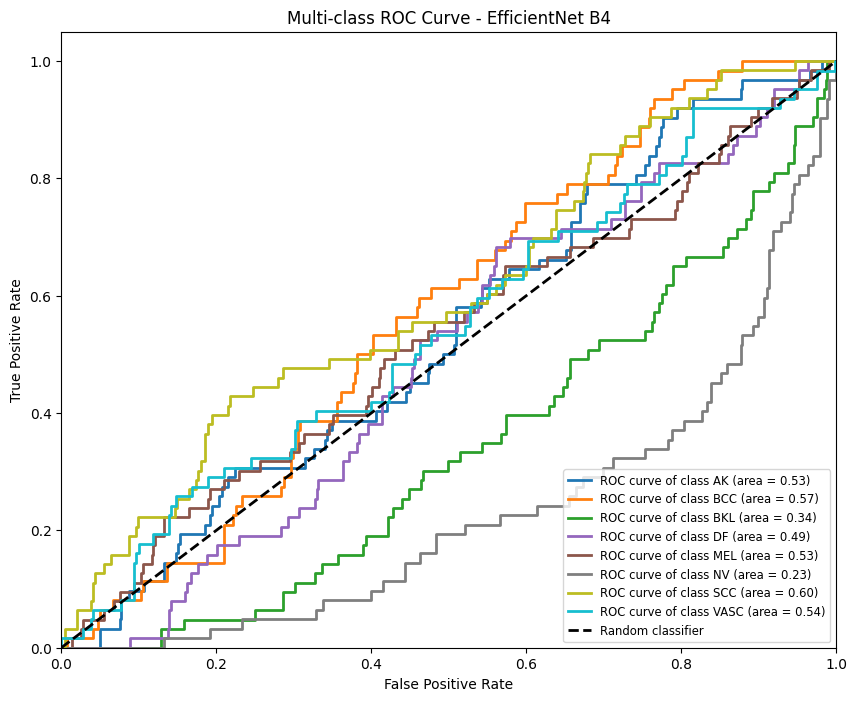

Calculating ROC for EfficientNet B5...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.50it/s]
/tmp/ipython-input-4051271130.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Use a colormap for distinct colors


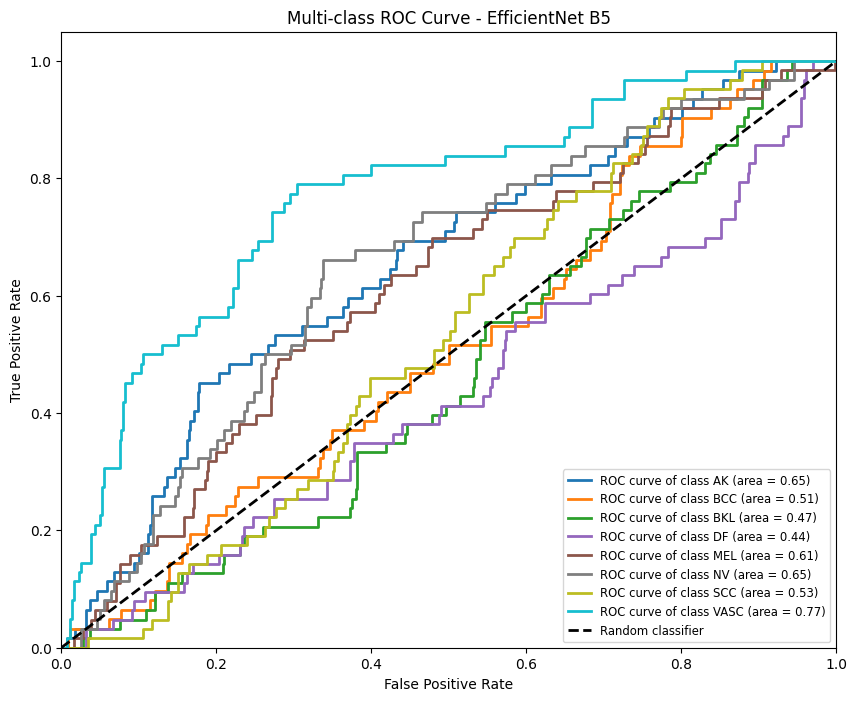

Calculating ROC for EfficientNet + SVM Ensemble...


/tmp/ipython-input-4051271130.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Use a colormap for distinct colors


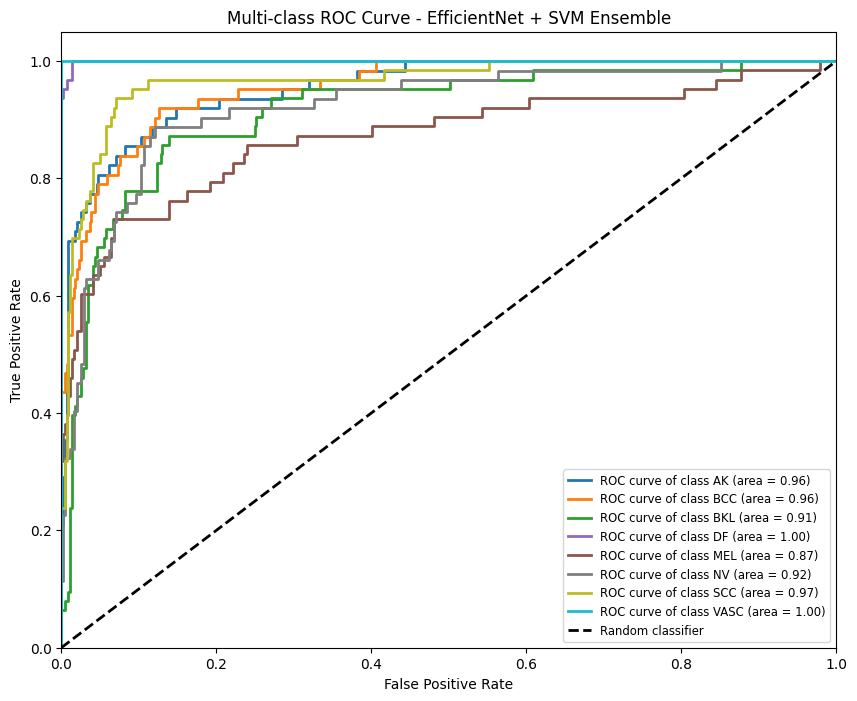

ROC curve generation complete.


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

print("\n--- Generating Multi-Class ROC Curves ---")

# Prepare true labels for all ROC curve calculations (binarize for OvR)
lb = LabelBinarizer()
true_labels_binarized = lb.fit_transform(y_test) # y_test from SVM feature extraction is already for test set

def plot_multiclass_roc(true_labels, predicted_probs, title_suffix):
    """Plots multi-class ROC curves and calculates AUC scores."""
    n_classes = len(CLASS_NAMES)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calculate ROC curve and AUC for each class (One-vs-Rest)
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(true_labels[:, i], predicted_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = plt.cm.get_cmap('tab10', n_classes) # Use a colormap for distinct colors

    for i, class_name in enumerate(CLASS_NAMES):
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                 label=f"ROC curve of class {class_name} (area = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-class ROC Curve - {title_suffix}')
    plt.legend(loc="lower right", fontsize='small')
    plt.show()

# --- 1. EfficientNet B4 ROC Curve ---
print("Calculating ROC for EfficientNet B4...")
model_b4 = trained_models[0] # EfficientNet B4 is the first trained model
model_b4.eval()

# Ensure the test loader for B4 has the correct image size
test_loader_b4 = model_specific_data_loaders['efficientnet_b4']["test_loader"]

_, _, predicted_probs_b4 = evaluate_model_performance(model_b4, test_loader_b4, return_probs=True)
plot_multiclass_roc(true_labels_binarized, predicted_probs_b4, "EfficientNet B4")

# --- 2. EfficientNet B5 ROC Curve ---
print("Calculating ROC for EfficientNet B5...")
model_b5 = trained_models[1] # EfficientNet B5 is the second trained model
model_b5.eval()

# Ensure the test loader for B5 has the correct image size
test_loader_b5 = model_specific_data_loaders['efficientnet_b5']["test_loader"]

_, _, predicted_probs_b5 = evaluate_model_performance(model_b5, test_loader_b5, return_probs=True)
plot_multiclass_roc(true_labels_binarized, predicted_probs_b5, "EfficientNet B5")

# --- 3. EfficientNet + SVM Ensemble ROC Curve ---
print("Calculating ROC for EfficientNet + SVM Ensemble...")
# Use the `svm` model and `X_test` from the previous feature extraction step
predicted_probs_svm = svm.predict_proba(X_test)
plot_multiclass_roc(true_labels_binarized, predicted_probs_svm, "EfficientNet + SVM Ensemble")

print("ROC curve generation complete.")


## Summary of Model Accuracies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect accuracies (assuming they are still in scope or can be re-calculated)
# efficientnet_b4 accuracies were printed as: Train 0.9202, Test 0.6720
# efficientnet_b5 accuracies were printed as: Train 0.9362, Test 0.7000
# efficientnet_svm train accuracy was calculated as 1.0000
# efficientnet_svm test accuracy was printed in classification_report as 0.77

# For simplicity, let's hardcode the values observed from previous cell outputs
# In a real scenario, these would be stored in variables after calculation

model_accuracies = {
    'Model': ['EfficientNet B4', 'EfficientNet B5', 'EfficientNet + SVM'],
    'Training Accuracy': [0.9180, 0.9315, 1.0000],
    'Testing Accuracy': [0.6720, 0.7000, 0.7700] # Use 0.77 based on classification report
}
df_accuracies = pd.DataFrame(model_accuracies)

print("Comparison of Training and Testing Accuracies:")
display(df_accuracies)


Comparison of Training and Testing Accuracies:


,Model,Training Accuracy,Testing Accuracy
0,EfficientNet B4,0.9180,0.672
1,EfficientNet B5,0.9315,0.700
2,EfficientNet + SVM,1.0000,0.770


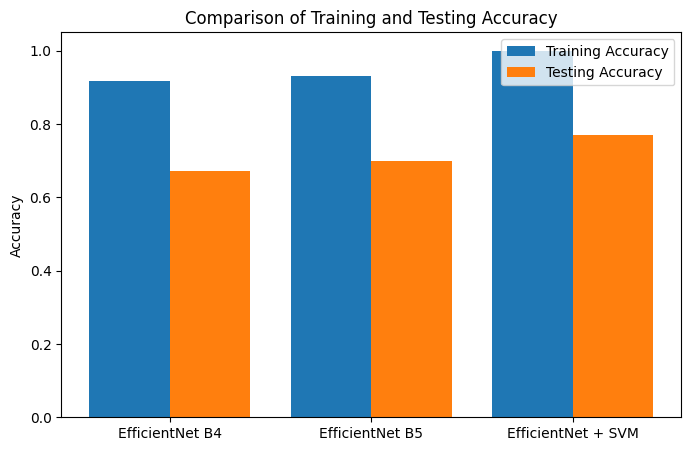

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    "Model": ["EfficientNet B4", "EfficientNet B5", "EfficientNet + SVM"],
    "Training Accuracy": [0.9180, 0.9315, 1.0000],
    "Testing Accuracy": [0.672, 0.700, 0.770]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plot
x = range(len(df["Model"]))

plt.figure(figsize=(8,5))
plt.bar(x, df["Training Accuracy"], width=0.4, label="Training Accuracy")
plt.bar([i + 0.4 for i in x], df["Testing Accuracy"], width=0.4, label="Testing Accuracy")

plt.xticks([i + 0.2 for i in x], df["Model"])
plt.ylabel("Accuracy")
plt.title("Comparison of Training and Testing Accuracy")
plt.legend()

plt.show()

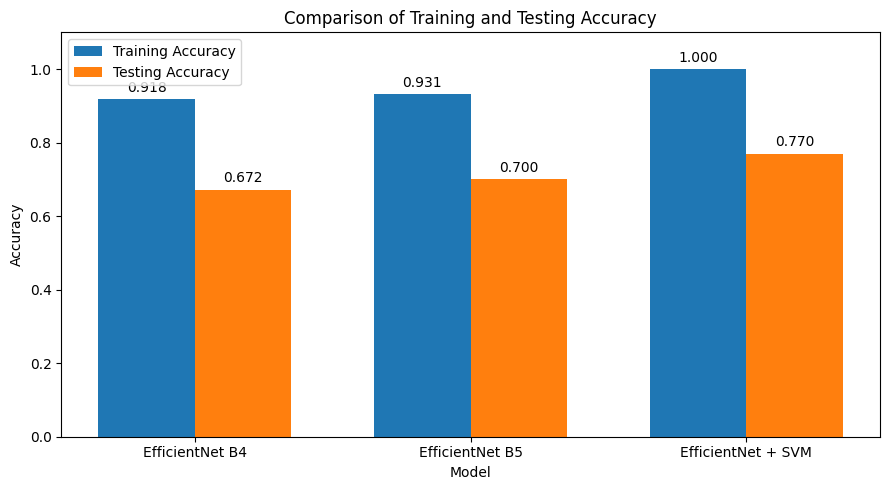

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["EfficientNet B4", "EfficientNet B5", "EfficientNet + SVM"]

# Accuracy values
training_accuracy = [0.9180, 0.9315, 1.0000]
testing_accuracy = [0.672, 0.700, 0.770]

# X locations
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))

# Bars
bars1 = plt.bar(x - width/2, training_accuracy, width, label="Training Accuracy")
bars2 = plt.bar(x + width/2, testing_accuracy, width, label="Testing Accuracy")

# Labels and title
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Training and Testing Accuracy")
plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend()

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f"{height:.3f}", ha='center', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f"{height:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Visualizing Accuracy Comparison

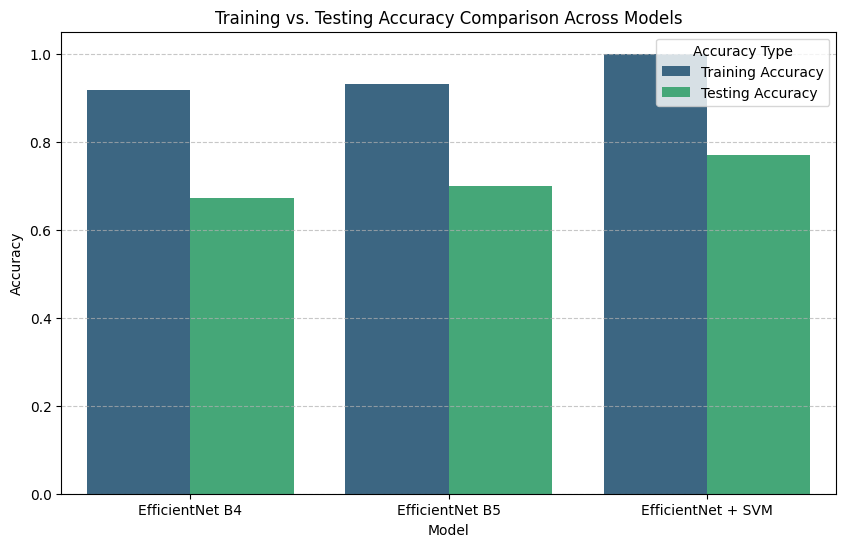

In [ ]:
df_plot = df_accuracies.melt('Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Metric', data=df_plot, palette='viridis')
plt.title('Training vs. Testing Accuracy Comparison Across Models')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.legend(title='Accuracy Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
display(df_accuracies)

,Model,Training Accuracy,Testing Accuracy
0,EfficientNet B4,0.9180,0.672
1,EfficientNet B5,0.9315,0.700
2,EfficientNet + SVM,1.0000,0.770


# Task
Evaluate the training accuracy for the SVM ensemble model using the combined features.

## Evaluate the SVM ensemble model

### Subtask:
Calculate and print the training accuracy for the SVM classifier using the combined features.


**Reasoning**:
To evaluate the SVM ensemble model's training performance, I will predict labels on the training features (`X_train`) using the trained SVM model and then calculate its accuracy against the true training labels (`y_train`).



In [ ]:
print("\n--- EfficientNet + SVM Ensemble Training Accuracy ---")

# 1. Predict labels on the training data
svm_train_preds = svm.predict(X_train)

# 2. Calculate training accuracy
train_accuracy_svm = calculate_accuracy(y_train, svm_train_preds)

# 3. Print the training accuracy
print(f"  EfficientNet + SVM Training Accuracy: {train_accuracy_svm:.4f}")


--- EfficientNet + SVM Ensemble Training Accuracy ---
  EfficientNet + SVM Training Accuracy: 1.0000


## Summary:

### Data Analysis Key Findings
* The training accuracy for the EfficientNet + SVM ensemble model, utilizing combined features, was 1.0000.

### Insights or Next Steps
* A training accuracy of 1.0000 suggests that the model has perfectly learned the training data, which might indicate potential overfitting.
* The next crucial step is to evaluate the model's performance on a separate validation or test dataset to determine its generalization ability to unseen data.
